# Projeto 1 · 00 — Análise exploratória do conjunto POP

**Objeto de estudo:** imagens térmicas aéreas e anotações de pessoas parcialmente ocluídas em ambientes naturais.

Este notebook caracteriza a distribuição das imagens, a estrutura das anotações e os fatores de aquisição
relevantes para o desenho experimental. As análises são descritivas: não envolvem treinamento, inferência de
modelos ou seleção de hiperparâmetros. Não há dependência de PyTorch, Ultralytics ou GPU.

**Referência:** Song, Z. et al. (2025). *An infrared dataset for partially occluded person detection in complex
 environment for search and rescue*. Scientific Data, 12, 300.
[Artigo e DOI](https://doi.org/10.1038/s41597-025-04600-0) ·
[Repositório oficial do dataset](https://osf.io/kmcva/overview).

A organização segue as Figuras 1, 4, 5, 7 e 8 e a Tabela 4 do artigo. As figuras abaixo são produzidas a partir
dos arquivos locais. Informações transcritas do artigo são identificadas como metadados externos.

### Contexto de aquisição

Segundo o artigo, a coleta utilizou um DJI Matrice 30T, câmera térmica na faixa de 8–14 µm e
visada aproximadamente vertical (gimbal a −90°). Participaram nove voluntários. O conjunto
é organizado em 19 cenas, com alturas nominais de 30, 50 e 70 m e quatro condições meteorológicas.
Os arquivos distribuídos têm resolução de 1280 × 1024 pixels.

A finalidade é estudar detecção de pessoas sob oclusão parcial por vegetação. As anotações
representam ocorrências em quadros, não identidades individuais. A exploração examina como
as condições de captura e a escala aparente dos alvos estão representadas nesse conjunto.

> A inspeção de todas as partições neste notebook limita-se à caracterização documental do dataset.
> Resultados de modelos no teste não devem orientar seleção de modelos, limiares ou hiperparâmetros.

## 1. Obtenção dos dados e organização local

Baixe **POP.zip** no [OSF](https://osf.io/kmcva/overview) e extraia-o em `projeto-1/dados`, preservando a
estrutura original. O arquivo auditado tem 643.136.554 bytes, aproximadamente 613 MiB. A pasta extraída
ocupa espaço adicional. As pastas `dados/` e `saidas-eda/` são ignoradas pelo Git.

O exemplo seguinte é **opcional e está integralmente comentado**. Não é executado automaticamente.
Se os dados já estiverem presentes, prossiga para a configuração do ambiente.

In [1]:
# Execute somente se desejar baixar e extrair o dataset, a partir da pasta projeto-1.
# from pathlib import Path
# import hashlib, urllib.request, zipfile
# destino = Path("dados")
# destino.mkdir(exist_ok=True)
# arquivo = destino / "POP.zip"
# urllib.request.urlretrieve("https://osf.io/download/gm8u2/", arquivo)
# esperado = "14e7c4ddffe6555de1da9033217a7d95981fa1bc63f9cd6a514c348e593741cf"
# with arquivo.open("rb") as f:
#     h = hashlib.sha256()
#     for bloco in iter(lambda: f.read(8 * 1024 * 1024), b""):
#         h.update(bloco)
# assert h.hexdigest() == esperado, "Download incompleto ou versão diferente do arquivo."
# with zipfile.ZipFile(arquivo) as z:
#     for item in z.infolist():
#         if not (destino / item.filename).resolve().is_relative_to(destino.resolve()):
#             raise ValueError("Caminho inválido no ZIP.")
#     z.extractall(destino)

### Ambiente de execução

São utilizados Python 3.10–3.12, pandas, NumPy, Pillow e Matplotlib, além de Jupyter para exibição.
O arquivo `requirements-eda.txt` permite instalar apenas esse ambiente, inclusive em Mac Intel.
Consulte o README para os comandos. Execute as células na ordem apresentada.

In [2]:
import hashlib
import json
import platform
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import PIL
from IPython.display import display

PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "00_analise_exploratoria.ipynb").is_file():
    PASTA_PROJETO = PASTA_PROJETO / "projeto-1"
POP = PASTA_PROJETO / "dados" / "POP"
SAIDAS = PASTA_PROJETO / "saidas-eda"
if not all((POP / s / "Annotations" / f"{s}.json").is_file() for s in ("train", "val", "test")):
    raise FileNotFoundError("Dataset não encontrado. Extraia POP.zip em projeto-1/dados, conforme a seção 1.")
SAIDAS.mkdir(exist_ok=True)

SEMENTE = 42
PARTICOES = ["train", "val", "test"]
NOMES = {"train": "Treino", "val": "Validação", "test": "Teste"}
CORES = {"train": "#24758C", "val": "#CC8536", "test": "#775994"}
CENAS = [f"F{i}" for i in range(1, 17)] + [f"T{i}" for i in range(1, 4)]
CLIMAS = ["Nuvens dispersas", "Encoberto", "Neblina", "Ensolarado"]
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "figure.dpi": 100, "savefig.dpi": 140,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold"})
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 12)


def exibir_figura(fig, nome):
    fig.savefig(SAIDAS / f"{nome}.png", bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)


def sha256(arquivo):
    h = hashlib.sha256()
    with Path(arquivo).open("rb") as f:
        for bloco in iter(lambda: f.read(1024 * 1024), b""):
            h.update(bloco)
    return h.hexdigest()


ambiente = {"Python": platform.python_version(), "NumPy": np.__version__,
            "pandas": pd.__version__, "Matplotlib": matplotlib.__version__, "Pillow": PIL.__version__}
display(pd.Series(ambiente, name="Versão").to_frame())

,Versão
Python,3.11.6
NumPy,1.26.4
pandas,2.3.3
Matplotlib,3.10.9
Pillow,12.3.0


## 2. Estrutura do dataset e significado dos nomes

A Figura 7 do artigo descreve três partições: treino (`F1`–`F12`), validação (`F13`–`F16`)
e teste (`T1`–`T3`). Cada partição contém imagens JPEG e um arquivo COCO de anotações.

```text
dados/POP/
├── train/
│   ├── JPEGImages/
│   └── Annotations/train.json
├── val/
│   ├── JPEGImages/
│   └── Annotations/val.json
└── test/
    ├── JPEGImages/
    └── Annotations/test.json
```

O nome `<cena>_<índice>_<altura>.JPG` identifica a cena, o índice da imagem dentro dela e a altura
relativa ao ponto de decolagem, em metros. Essa altura **não equivale necessariamente à distância ao solo
sob a câmera**. O índice, isoladamente, também não comprova a ordem temporal dos registros.

Os identificadores COCO são locais a cada partição. Por isso, toda associação entre imagem e anotação
utiliza a chave composta `(partição, image_id)`.

In [3]:
documentos = {}
linhas_imagens, linhas_caixas = [], []
campos_anotacoes = set()
for split in PARTICOES:
    doc = json.loads((POP / split / "Annotations" / f"{split}.json").read_text(encoding="utf-8"))
    documentos[split] = doc
    assert doc["categories"] == [{"name": "person", "id": 1}], "Categoria inesperada."
    ids = [im["id"] for im in doc["images"]]
    assert len(ids) == len(set(ids)), f"ID de imagem repetido em {split}."
    ids_anotacoes = [a["id"] for a in doc["annotations"]]
    assert len(ids_anotacoes) == len(set(ids_anotacoes)), f"ID de anotação repetido em {split}."
    for im in doc["images"]:
        nome = im["file_name"]
        match = re.fullmatch(r"([FT]\d+)_(\d+)_([0-9.]+)\.JPG", nome, flags=re.IGNORECASE)
        if match is None:
            raise ValueError(f"Nome de imagem não reconhecido: {nome}")
        cena, indice, altura = match.groups()
        linhas_imagens.append({"split": split, "image_id": im["id"], "arquivo": nome,
                               "arquivo_relativo": f"{split}/JPEGImages/{nome}",
                               "cena": cena, "indice": int(indice), "altura_m": float(altura),
                               "largura": im["width"], "altura": im["height"]})
    for a in doc["annotations"]:
        campos_anotacoes.update(a)
        x, y, w, h = a["bbox"]
        linhas_caixas.append({"split": split, "annotation_id": a["id"], "image_id": a["image_id"],
                             "category_id": a["category_id"], "x": x, "y": y, "w": w, "h": h,
                             "area_coco": a.get("area"), "iscrowd": a.get("iscrowd"),
                             "segmentacao_presente": a.get("segmentation") is not None})

imagens = pd.DataFrame(linhas_imagens)
caixas = pd.DataFrame(linhas_caixas).merge(imagens, on=["split", "image_id"], how="left",
                                         validate="many_to_one", indicator=True)
assert caixas["_merge"].eq("both").all(), "Há anotações sem imagem correspondente."
caixas = caixas.drop(columns="_merge")
contagens = caixas.groupby(["split", "image_id"]).size().rename("pessoas")
imagens = imagens.merge(contagens, on=["split", "image_id"], how="left", validate="one_to_one")
imagens["pessoas"] = imagens["pessoas"].fillna(0).astype(int)
assert not imagens.duplicated(["split", "arquivo"]).any()
assert np.isfinite(caixas[["x", "y", "w", "h"]].to_numpy()).all()
assert caixas["category_id"].eq(1).all()
assert ((caixas.w > 0) & (caixas.h > 0) & (caixas.x >= 0) & (caixas.y >= 0)).all()
assert ((caixas.x + caixas.w <= caixas.largura + 1e-5) &
        (caixas.y + caixas.h <= caixas.altura + 1e-5)).all()

# Área geométrica calculada; o campo area do arquivo não é utilizado como medida da caixa.
caixas["area_px2"] = caixas.w * caixas.h
caixas["menor_lado_px"] = caixas[["w", "h"]].min(axis=1)
caixas["escala_px"] = np.sqrt(caixas.area_px2)
caixas["razao_lados"] = caixas.w / caixas.h
caixas["area_relativa_pct"] = 100 * caixas.area_px2 / (caixas.largura * caixas.altura)
caixas["centro_x_norm"] = (caixas.x + caixas.w / 2) / caixas.largura
caixas["centro_y_norm"] = (caixas.y + caixas.h / 2) / caixas.altura
for df in (imagens, caixas):
    df["faixa_altitude_m"] = np.array([30, 50, 70])[np.abs(df.altura_m.to_numpy()[:, None] - [30, 50, 70]).argmin(axis=1)]

display(imagens[["split", "image_id", "arquivo", "cena", "altura_m", "pessoas"]].head())
display(caixas[["split", "annotation_id", "image_id", "x", "y", "w", "h", "area_coco", "area_px2"]].head())

,split,image_id,arquivo,cena,altura_m,pessoas
0,train,1,F10_0000_30.145.JPG,F10,30.145,4
1,train,2,F10_0001_69.974.JPG,F10,69.974,4
2,train,3,F10_0002_49.854.JPG,F10,49.854,3
3,train,4,F10_0003_30.123.JPG,F10,30.123,4
4,train,5,F10_0004_49.885.JPG,F10,49.885,4


,split,annotation_id,image_id,x,y,w,h,area_coco,area_px2
0,train,1,31,618,527,44,32,1.1,1408
1,train,2,31,377,513,19,40,1.1,760
2,train,3,31,426,637,16,20,1.1,320
3,train,4,92,548,453,27,46,1.1,1242
4,train,5,92,791,466,44,39,1.1,1716


## 3. Integridade, dimensões e campos disponíveis

As verificações seguintes inspecionam todos os arquivos referenciados, suas dimensões e seus hashes.
Uma duplicata por SHA-256 representa igualdade do arquivo codificado; a ausência de duplicatas não exclui
imagens visualmente semelhantes. A verificação por Pillow examina a estrutura do arquivo e não substitui
uma inspeção visual de todas as imagens.

O pacote distribuído contém imagens térmicas. Um JPEG com três canais não constitui, por si só, uma imagem
de luz visível: imagens monocromáticas podem ser armazenadas com canais RGB redundantes. Os níveis de
cinza de um JPEG também **não são temperaturas calibradas**.

In [4]:
registros_integridade = []
for linha in imagens.itertuples():
    caminho = POP / linha.arquivo_relativo
    with Image.open(caminho) as img:
        tamanho, modo = img.size, img.mode
        img.verify()
    if tamanho != (linha.largura, linha.altura):
        raise ValueError(f"Dimensões incompatíveis com o COCO: {linha.arquivo}")
    registros_integridade.append({"arquivo_relativo": linha.arquivo_relativo,
                                 "modo": modo, "sha256": sha256(caminho)})
integridade = pd.DataFrame(registros_integridade)
imagens = imagens.merge(integridade, on="arquivo_relativo", validate="one_to_one")
resumo = imagens.groupby("split").agg(imagens=("image_id", "size"), caixas=("pessoas", "sum"),
                                      cenas=("cena", "nunique"),
                                      imagens_sem_pessoas=("pessoas", lambda x: int((x == 0).sum())))
resumo = resumo.reindex(PARTICOES)
resumo["pessoas_por_imagem"] = resumo.caixas / resumo.imagens
resumo["percentual_imagens"] = 100 * resumo.imagens / len(imagens)
display(resumo.round(2).rename(index=NOMES))
display(imagens.groupby(["largura", "altura", "modo"]).size().rename("imagens").to_frame())
print("Campos das anotações:", ", ".join(sorted(campos_anotacoes)))
print("Valores de area:", sorted(caixas.area_coco.unique()))
print("Caixas cujo campo area difere de largura × altura:", int((~np.isclose(caixas.area_coco, caixas.area_px2)).sum()))
print("Valores de iscrowd:", sorted(caixas.iscrowd.unique()))
print("Anotações com segmentação:", int(caixas.segmentacao_presente.sum()))

arquivo_zip = POP.parent / "POP.zip"
if arquivo_zip.is_file():
    assert sha256(arquivo_zip) == "14e7c4ddffe6555de1da9033217a7d95981fa1bc63f9cd6a514c348e593741cf"
    print("SHA-256 do ZIP corresponde à versão auditada.")

,imagens,caixas,cenas,imagens_sem_pessoas,pessoas_por_imagem,percentual_imagens
split,,,,,,
Treino,5548,18425,12,0,3.32,63.28
Validação,2320,6546,4,0,2.82,26.46
Teste,900,1840,3,0,2.04,10.26


,,,imagens
largura,altura,modo,
1280,1024,RGB,8768


Campos das anotações: area, bbox, category_id, id, image_id, iscrowd, segmentation
Valores de area: [1.1]
Caixas cujo campo area difere de largura × altura: 26811
Valores de iscrowd: [0]
Anotações com segmentação: 0


SHA-256 do ZIP corresponde à versão auditada.


### Interpretação da auditoria

Na versão auditada, todas as caixas têm `area=1.1`, valor incompatível com sua área geométrica em pixels.
As análises de tamanho utilizam `w × h`, calculado a partir de `bbox`. `segmentation` não fornece máscaras,
e `iscrowd` não deve ser interpretado como indicador de oclusão.

O total de caixas calculado deve ser confrontado com duas fontes distintas: o texto do artigo declara
25.811; a soma da Tabela 4 e os arquivos distribuídos produzem 26.811. Uma divergência documental deve
ser registrada, sem ajustar artificialmente as contagens observadas.

In [5]:
comparacao_totais = pd.DataFrame({"Fonte": ["Arquivos COCO locais", "Texto do artigo"],
                                 "Imagens": [len(imagens), 8768], "Caixas": [len(caixas), 25811]})
display(comparacao_totais)
print("Diferença de caixas entre arquivos locais e texto:", len(caixas) - 25811)

,Fonte,Imagens,Caixas
0,Arquivos COCO locais,8768,26811
1,Texto do artigo,8768,25811


Diferença de caixas entre arquivos locais e texto: 1000


## 4. Metadados das cenas: reprodução e conferência da Tabela 4

Clima, vegetação, coordenadas, horário e velocidade não constam nos JSONs COCO utilizados aqui.
A tabela seguinte transcreve esses atributos da **Tabela 4 do artigo** e os associa por identificador de cena.
O clima é, portanto, um atributo documental da cena, não uma classificação estimada a partir dos pixels.

São preservadas as siglas de vegetação originais. A sigla `PR`, presente em algumas linhas da tabela,
não é expandida na legenda e permanece sem interpretação adicional.

In [6]:
# Fonte externa: Song et al. (2025), Tabela 4. As contagens observadas serão calculadas separadamente.
linhas_artigo = [
    ("F1", "train", "Cloudy", "CD", 6.5, 220, 850, "34°18′17″ N, 108°57′53″ E", "2023-11-10 06:07"),
    ("F2", "train", "Cloudy", "CD", 2.13, 388, 1676, "34°18′17″ N, 108°57′53″ E", "2023-11-10 10:23"),
    ("F3", "train", "Cloudy", "CD", 3.42, 589, 1805, "34°18′17″ N, 108°57′53″ E", "2023-11-10 17:19"),
    ("F4", "train", "Overcast", "PT, ST", 1.77, 297, 1350, "34°6′55″ N, 108°55′10″ E", "2023-11-28 07:29"),
    ("F5", "train", "Overcast", "PT, ST", 2.02, 532, 2412, "34°6′55″ N, 108°55′10″ E", "2023-11-28 10:31"),
    ("F6", "train", "Overcast", "PT, ST", 2.41, 786, 2669, "34°22′59″ N, 108°59′29″ E", "2023-12-02 16:43"),
    ("F7", "train", "Foggy", "PV", 1.5, 318, 985, "34°10′39″ N, 109°2′9″ E", "2024-01-16 06:53"),
    ("F8", "train", "Foggy", "PV", 2.0, 689, 1730, "34°10′39″ N, 109°2′9″ E", "2024-01-16 09:16"),
    ("F9", "train", "Foggy", "PV", 2.4, 483, 1142, "34°10′39″ N, 109°2′9″ E", "2024-01-16 17:52"),
    ("F10", "train", "Overcast", "CR, PV", 2.2, 419, 1463, "34°23′7″ N, 108°59′32″ E", "2024-02-01 06:42"),
    ("F11", "train", "Overcast", "CR, PV", 1.8, 623, 1589, "34°23′7″ N, 108°59′32″ E", "2024-02-01 09:27"),
    ("F12", "train", "Overcast", "CR, PV", 1.4, 204, 754, "34°23′7″ N, 108°59′32″ E", "2024-02-01 17:13"),
    ("F13", "val", "Sunny", "PB, PR, WW", 2.21, 550, 1748, "34°17′53″ N, 109°10′24″ E", "2024-03-28 09:35"),
    ("F14", "val", "Sunny", "PB, PR, WW", 2.8, 508, 1709, "34°17′53″ N, 109°10′24″ E", "2024-03-28 16:23"),
    ("F15", "val", "Sunny", "PB, PR, WW", 5.14, 401, 1318, "34°25′35″ N, 109°0′30″ E", "2024-04-11 07:17"),
    ("F16", "val", "Sunny", "SP, WW, CT", 4.70, 861, 1771, "34°25′35″ N, 109°0′30″ E", "2024-04-11 16:34"),
    ("T1", "test", "Cloudy", "CD, PA, ST", 1.6, 306, 501, "34°22′59″ N, 108°59′29″ E", "2024-04-12 06:54"),
    ("T2", "test", "Sunny", "JT", 2.3, 258, 686, "34°25′58″ N, 109°1′10″ E", "2024-04-17 08:27"),
    ("T3", "test", "Cloudy", "CY", 2.1, 336, 653, "34°27′44″ N, 109°4′40″ E", "2024-04-21 07:14"),
]
metadados = pd.DataFrame(linhas_artigo, columns=["cena", "split_artigo", "clima_original", "vegetacao",
                                               "velocidade_max_m_s", "imagens_artigo", "caixas_artigo",
                                               "coordenadas_artigo", "registro_artigo"])
metadados["clima"] = metadados.clima_original.map({"Cloudy": "Nuvens dispersas", "Overcast": "Encoberto",
                                                  "Foggy": "Neblina", "Sunny": "Ensolarado"})
metadados["registro_artigo"] = pd.to_datetime(metadados.registro_artigo)
def associar_metadados(tabela):
    resultado = tabela.merge(metadados, on="cena", how="left", validate="many_to_one")
    assert resultado.clima.notna().all(), "Cena sem metadados na Tabela 4."
    assert resultado.split.eq(resultado.split_artigo).all(), "Partição divergente da Tabela 4."
    return resultado


imagens = associar_metadados(imagens)
caixas = associar_metadados(caixas)

por_cena = imagens.groupby("cena").agg(imagens_observadas=("image_id", "size"),
                                      caixas_observadas=("pessoas", "sum"),
                                      pessoas_por_imagem=("pessoas", "mean"))
tabela_cenas = metadados.set_index("cena").join(por_cena).reindex(CENAS)
tabela_cenas["dif_imagens"] = tabela_cenas.imagens_observadas - tabela_cenas.imagens_artigo
tabela_cenas["dif_caixas"] = tabela_cenas.caixas_observadas - tabela_cenas.caixas_artigo
display(tabela_cenas[["split_artigo", "clima", "vegetacao", "imagens_observadas", "caixas_observadas",
                     "pessoas_por_imagem", "dif_imagens", "dif_caixas"]].round(2))
display(metadados[["cena", "velocidade_max_m_s", "coordenadas_artigo", "registro_artigo"]])
print("Soma de caixas na Tabela 4:", int(metadados.caixas_artigo.sum()))

,split_artigo,clima,vegetacao,imagens_observadas,caixas_observadas,pessoas_por_imagem,dif_imagens,dif_caixas
cena,,,,,,,,
F1,train,Nuvens dispersas,CD,220,850,3.86,0,0
F2,train,Nuvens dispersas,CD,388,1676,4.32,0,0
F3,train,Nuvens dispersas,CD,589,1805,3.06,0,0
F4,train,Encoberto,"PT, ST",297,1350,4.55,0,0
F5,train,Encoberto,"PT, ST",532,2412,4.53,0,0
F6,train,Encoberto,"PT, ST",786,2669,3.40,0,0
F7,train,Neblina,PV,318,985,3.10,0,0
F8,train,Neblina,PV,689,1730,2.51,0,0
F9,train,Neblina,PV,483,1142,2.36,0,0


,cena,velocidade_max_m_s,coordenadas_artigo,registro_artigo
0,F1,6.50,"34°18′17″ N, 108°57′53″ E",2023-11-10 06:07:00
1,F2,2.13,"34°18′17″ N, 108°57′53″ E",2023-11-10 10:23:00
2,F3,3.42,"34°18′17″ N, 108°57′53″ E",2023-11-10 17:19:00
3,F4,1.77,"34°6′55″ N, 108°55′10″ E",2023-11-28 07:29:00
4,F5,2.02,"34°6′55″ N, 108°55′10″ E",2023-11-28 10:31:00
5,F6,2.41,"34°22′59″ N, 108°59′29″ E",2023-12-02 16:43:00
6,F7,1.50,"34°10′39″ N, 109°2′9″ E",2024-01-16 06:53:00
7,F8,2.00,"34°10′39″ N, 109°2′9″ E",2024-01-16 09:16:00
8,F9,2.40,"34°10′39″ N, 109°2′9″ E",2024-01-16 17:52:00
9,F10,2.20,"34°23′7″ N, 108°59′32″ E",2024-02-01 06:42:00


Soma de caixas na Tabela 4: 26811


## 5. Distribuição de imagens e caixas por cena

Os gráficos retomam a Figura 8(a), adicionando a identificação das partições. O número de caixas representa
**ocorrências anotadas de pessoas nas imagens**, não o número de indivíduos únicos. Um participante pode
aparecer em diversas imagens. Cenas maiores contribuem mais para métricas calculadas sobre todo o conjunto.

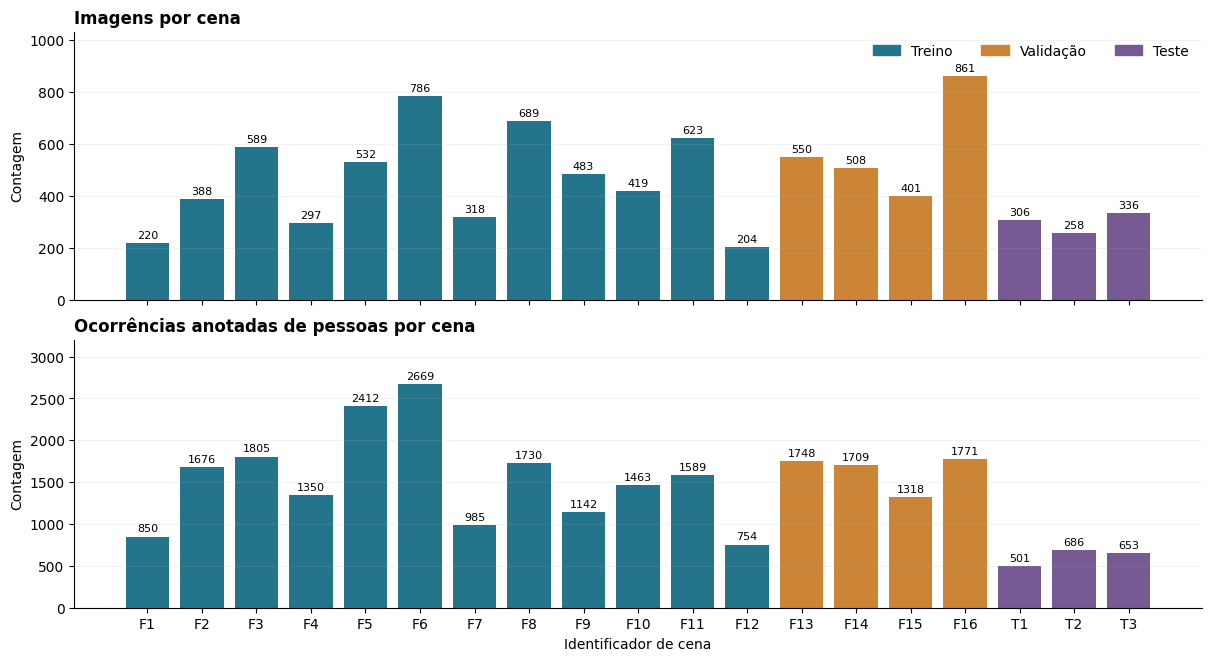

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, layout="constrained")
cores = tabela_cenas.split_artigo.map(CORES)
for ax, coluna, titulo in zip(axes, ["imagens_observadas", "caixas_observadas"],
                              ["Imagens por cena", "Ocorrências anotadas de pessoas por cena"]):
    barras = ax.bar(CENAS, tabela_cenas[coluna], color=cores)
    ax.bar_label(barras, fontsize=8, padding=2)
    ax.set_ylim(0, tabela_cenas[coluna].max() * 1.2)
    ax.set_ylabel("Contagem")
    ax.set_title(titulo, loc="left")
    ax.grid(axis="y", alpha=.15)
axes[1].set_xlabel("Identificador de cena")
axes[0].legend(handles=[Rectangle((0, 0), 1, 1, color=CORES[s], label=NOMES[s]) for s in PARTICOES],
               loc="upper right", ncol=3, frameon=False)
exibir_figura(fig, "01_contagens_por_cena")

## 6. Altitudes de aquisição e exemplos visuais

A altura é extraída do nome do arquivo. Para resumir a distribuição como na Figura 8(b), cada registro é
associado ao valor nominal mais próximo entre 30, 50 e 70 m. Trata-se de uma **regra analítica explícita**,
e não de recuperação de um comando de voo. As medidas contínuas e seus intervalos são apresentados
para não ocultar a variação dentro das faixas.

,imagens,minimo_m,mediana_m,maximo_m
faixa_altitude_m,,,,
30,2758,28.50,30.28,39.54
50,3548,40.33,50.09,58.42
70,2462,63.82,70.19,76.34


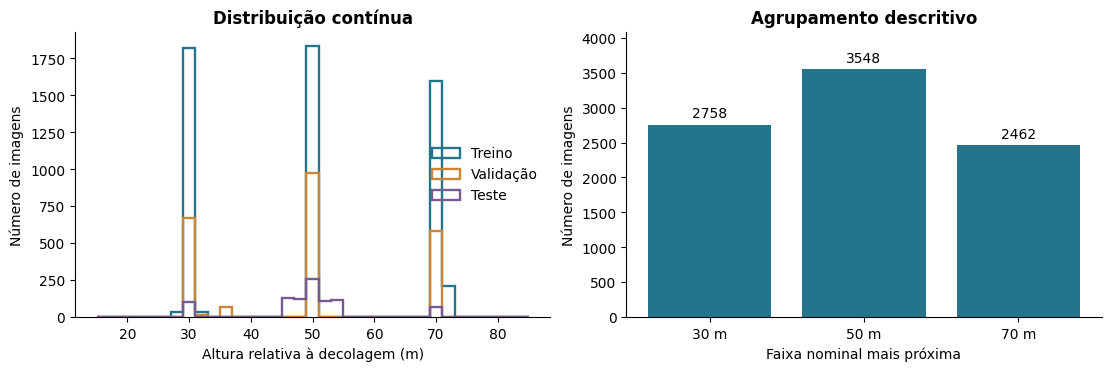

In [8]:
altitudes = imagens.groupby("faixa_altitude_m").agg(imagens=("image_id", "size"),
    minimo_m=("altura_m", "min"), mediana_m=("altura_m", "median"), maximo_m=("altura_m", "max"))
display(altitudes.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
for s in PARTICOES:
    axes[0].hist(imagens.loc[imagens.split == s, "altura_m"], bins=np.arange(15, 86, 2),
                 histtype="step", linewidth=1.7, label=NOMES[s], color=CORES[s])
axes[0].set(xlabel="Altura relativa à decolagem (m)", ylabel="Número de imagens", title="Distribuição contínua")
axes[0].legend(frameon=False)
b = axes[1].bar(["30 m", "50 m", "70 m"], altitudes.imagens.reindex([30, 50, 70]), color="#24758C")
axes[1].bar_label(b, padding=3)
axes[1].set(xlabel="Faixa nominal mais próxima", ylabel="Número de imagens", title="Agrupamento descritivo")
axes[1].set_ylim(0, altitudes.imagens.max() * 1.15)
exibir_figura(fig, "02_distribuicao_altitudes")

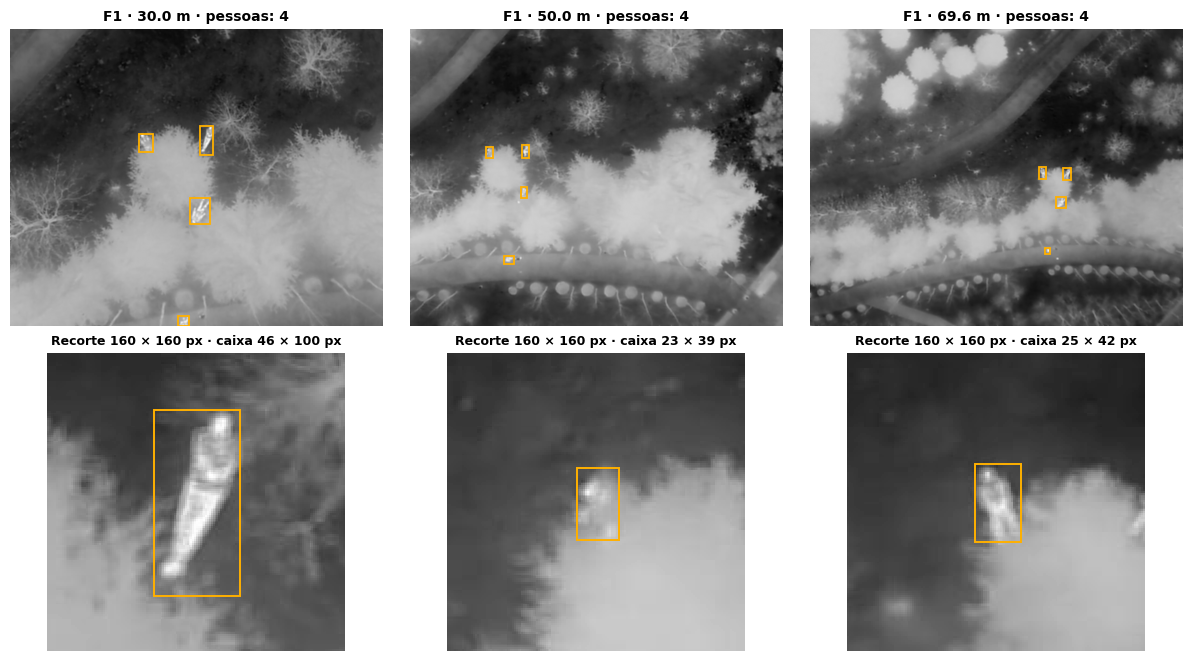

Imagens selecionadas: F1_0018_30.03.JPG; F1_0167_50.003.JPG; F1_0089_69.62.JPG


In [9]:
def anotacoes_da_imagem(linha):
    return caixas[(caixas.split == linha.split) & (caixas.image_id == linha.image_id)]


def imagem_anotada(ax, linha, titulo):
    with Image.open(POP / linha.arquivo_relativo) as img:
        pixels = np.asarray(img.convert("L"))
    ax.imshow(pixels, cmap="gray", vmin=0, vmax=255)
    for box in anotacoes_da_imagem(linha).itertuples():
        ax.add_patch(Rectangle((box.x, box.y), box.w, box.h, fill=False, edgecolor="#FFB000", linewidth=1.3))
    ax.set_title(titulo, fontsize=10)
    ax.set_axis_off()
    return pixels


# Uma mesma cena de treino, com registros disponíveis nas três faixas.
disponibilidade = pd.crosstab(imagens.cena, imagens.faixa_altitude_m).reindex(columns=[30, 50, 70], fill_value=0)
cena_exemplo = next(c for c in CENAS[:12] if disponibilidade.loc[c].gt(0).all())
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5), layout="constrained")
selecionadas_altitude = []
for j, nominal in enumerate([30, 50, 70]):
    candidatas = imagens[(imagens.cena == cena_exemplo) & (imagens.faixa_altitude_m == nominal)].copy()
    linha = candidatas.assign(distancia=(candidatas.altura_m - nominal).abs()).sort_values(["distancia", "arquivo"]).iloc[0]
    selecionadas_altitude.append(linha.arquivo)
    pixels = imagem_anotada(axes[0, j], linha, f"{linha.cena} · {linha.altura_m:.1f} m · pessoas: {linha.pessoas}")
    grupo = anotacoes_da_imagem(linha)
    box = grupo.loc[(grupo.area_px2 - grupo.area_px2.median()).abs().idxmin()]
    # Janela fixa de 160 × 160 pixels para comparar escala sem ampliar caixas individualmente.
    cx, cy = int(box.x + box.w / 2), int(box.y + box.h / 2)
    x0 = min(max(cx - 80, 0), pixels.shape[1] - 160)
    y0 = min(max(cy - 80, 0), pixels.shape[0] - 160)
    axes[1, j].imshow(pixels[y0:y0+160, x0:x0+160], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    axes[1, j].add_patch(Rectangle((box.x-x0, box.y-y0), box.w, box.h, fill=False, edgecolor="#FFB000", linewidth=1.4))
    axes[1, j].set_title(f"Recorte 160 × 160 px · caixa {box.w:g} × {box.h:g} px", fontsize=9)
    axes[1, j].set_axis_off()
exibir_figura(fig, "03_exemplos_altitudes")
print("Imagens selecionadas:", "; ".join(selecionadas_altitude))

As caixas destacam as anotações COCO. Os recortes têm o mesmo tamanho em pixels e não representam
necessariamente a mesma pessoa nem a mesma posição no terreno. Mesmo dentro de uma cena, a comparação
é ilustrativa; não constitui um experimento controlado sobre o efeito da altitude.

## 7. Condições meteorológicas e composição das partições

As Figuras 5 e 8(c) motivam a descrição por clima. As categorias são traduzidas como nuvens dispersas
(*cloudy*), encoberto (*overcast*), neblina (*foggy*) e ensolarado (*sunny*), preservando a classificação dos
autores. Não se estima nebulosidade a partir da aparência térmica.

split,Treino,Validação,Teste
clima,,,
Nuvens dispersas,1197,0,642
Encoberto,2861,0,0
Neblina,1490,0,0
Ensolarado,0,2320,258


split,Treino,Validação,Teste
Clima (% da partição),,,
Nuvens dispersas,21.6,0.0,71.3
Encoberto,51.6,0.0,0.0
Neblina,26.9,0.0,0.0
Ensolarado,0.0,100.0,28.7


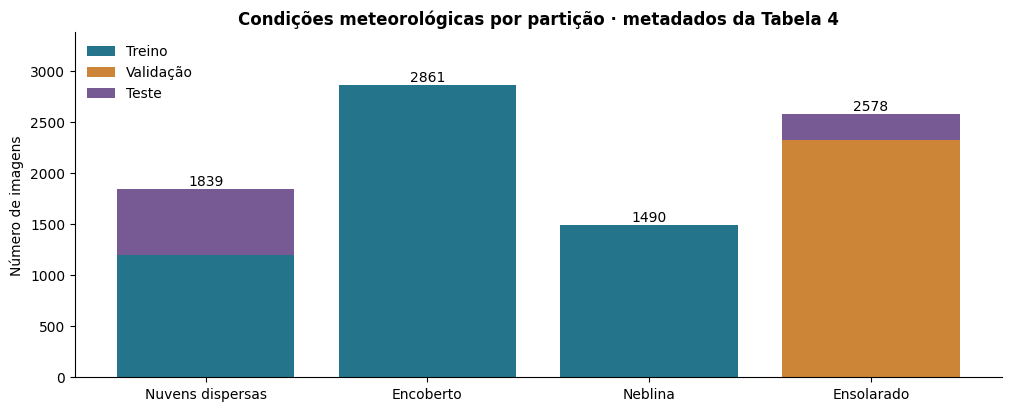

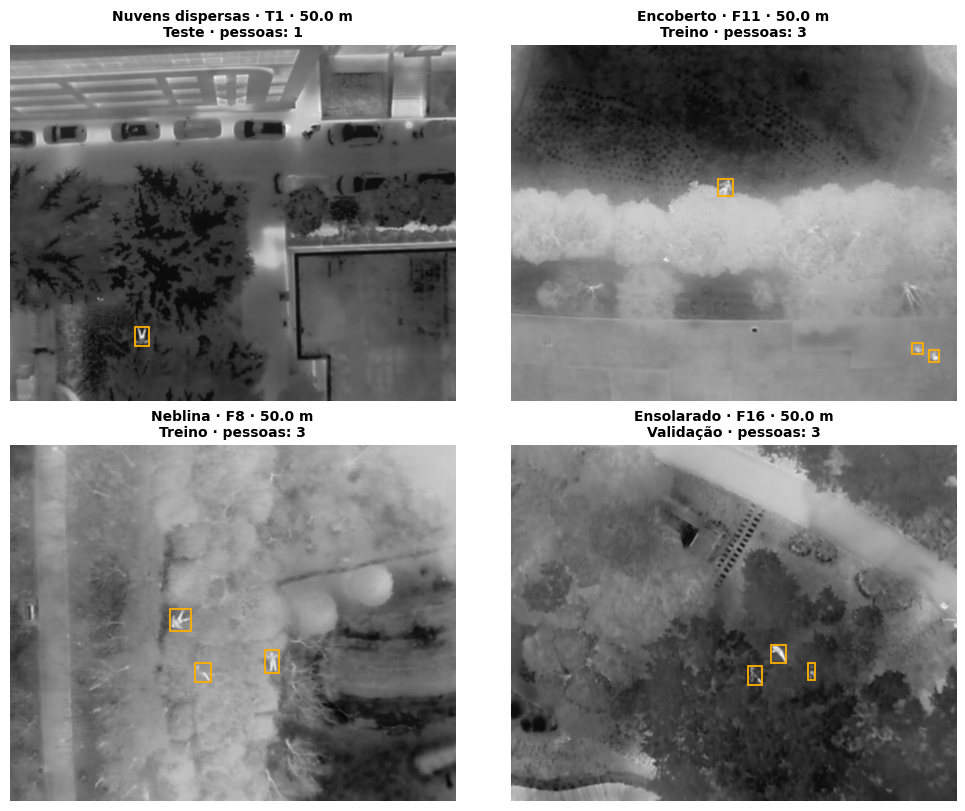

In [10]:
clima_split = pd.crosstab(imagens.clima, imagens.split).reindex(index=CLIMAS, columns=PARTICOES, fill_value=0)
clima_split_pct = 100 * clima_split.div(clima_split.sum(axis=0), axis=1)
display(clima_split.rename(columns=NOMES))
display(clima_split_pct.round(1).rename(columns=NOMES).rename_axis("Clima (% da partição)"))
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
fundo = np.zeros(len(CLIMAS))
for s in PARTICOES:
    ax.bar(CLIMAS, clima_split[s], bottom=fundo, color=CORES[s], label=NOMES[s])
    fundo += clima_split[s].to_numpy()
for x, total in enumerate(fundo):
    ax.text(x, total + 35, str(int(total)), ha="center", fontsize=10)
ax.set_ylim(0, fundo.max() * 1.18)
ax.set(ylabel="Número de imagens", title="Condições meteorológicas por partição · metadados da Tabela 4")
ax.legend(frameon=False)
exibir_figura(fig, "04_clima_por_particao")

fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout="constrained")
for ax, clima in zip(axes.flat, CLIMAS):
    candidatas = imagens[imagens.clima == clima].copy()
    linha = candidatas.assign(distancia=(candidatas.altura_m - 50).abs()).sort_values(["distancia", "arquivo"]).iloc[0]
    imagem_anotada(ax, linha, f"{clima} · {linha.cena} · {linha.altura_m:.1f} m\n{NOMES[linha.split]} · pessoas: {linha.pessoas}")
exibir_figura(fig, "05_exemplos_clima")

**Limite de interpretação.** Na Tabela 4, as cenas de validação são ensolaradas e o treino não contém essa
categoria. Clima, vegetação, local e data não variam de forma independente. Portanto, uma diferença futura
de desempenho entre partições não poderá ser atribuída exclusivamente a um desses fatores.

## 8. Tamanho aparente, proporção das caixas e densidade de pessoas

O tamanho aparente é descrito pelo menor lado, pela área geométrica e pela razão entre largura e altura.
Essas medidas descrevem a **caixa anotada**, não a área corporal visível nem a taxa de oclusão.

Além das distribuições, calcula-se o efeito geométrico de reduzir a maior dimensão da imagem de 1280 para
640 pixels: cada lado é multiplicado por 0,5 e cada área por 0,25. Isso descreve a perda de resolução espacial,
sem antecipar um resultado de detecção.

,caixas,menor_lado_p10,menor_lado_mediano,menor_lado_p90,area_mediana_px2,area_mediana_pct,menor_lado_abaixo_20_pct
split,,,,,,,
Treino,18425,20.0,34.0,65.0,1540.0,0.117,8.847
Validação,6546,23.0,37.0,64.0,1943.5,0.148,4.048
Teste,1840,21.0,31.0,44.0,1512.0,0.115,5.978


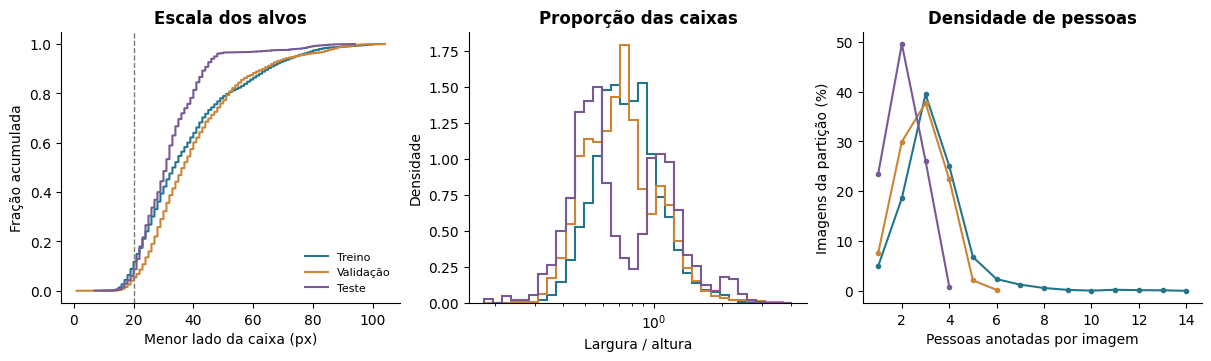

,Maior dimensão da imagem (px),Mediana do menor lado (px),Caixas com menor lado abaixo de 20 px (%)
0,1280,34.0,7.48
1,640,17.0,62.06


In [11]:
estatisticas_tamanho = caixas.groupby("split").agg(
    caixas=("annotation_id", "size"), menor_lado_p10=("menor_lado_px", lambda x: x.quantile(.1)),
    menor_lado_mediano=("menor_lado_px", "median"), menor_lado_p90=("menor_lado_px", lambda x: x.quantile(.9)),
    area_mediana_px2=("area_px2", "median"), area_mediana_pct=("area_relativa_pct", "median"),
    menor_lado_abaixo_20_pct=("menor_lado_px", lambda x: 100 * x.lt(20).mean()))
display(estatisticas_tamanho.reindex(PARTICOES).round(3).rename(index=NOMES))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")
for s in PARTICOES:
    grupo = caixas[caixas.split == s]
    ordenados = np.sort(grupo.menor_lado_px)
    axes[0].plot(ordenados, np.arange(1, len(ordenados)+1)/len(ordenados), color=CORES[s], label=NOMES[s])
    axes[1].hist(grupo.razao_lados, bins=np.geomspace(caixas.razao_lados.min(), caixas.razao_lados.max(), 35),
                 histtype="step", density=True, linewidth=1.5, color=CORES[s])
    freq = imagens.loc[imagens.split == s, "pessoas"].value_counts(normalize=True).sort_index()
    axes[2].plot(freq.index, freq * 100, marker="o", markersize=3, color=CORES[s])
axes[0].set(xlabel="Menor lado da caixa (px)", ylabel="Fração acumulada", title="Escala dos alvos")
axes[0].axvline(20, color="#777777", linestyle="--", linewidth=1)
axes[0].legend(frameon=False, fontsize=8)
axes[1].set(xlabel="Largura / altura", ylabel="Densidade", xscale="log", title="Proporção das caixas")
axes[2].set(xlabel="Pessoas anotadas por imagem", ylabel="Imagens da partição (%)", title="Densidade de pessoas")
exibir_figura(fig, "06_geometria_e_densidade")

reducao = pd.DataFrame({"Maior dimensão da imagem (px)": [1280, 640],
    "Mediana do menor lado (px)": [caixas.menor_lado_px.median(), caixas.menor_lado_px.median()/2],
    "Caixas com menor lado abaixo de 20 px (%)": [100 * caixas.menor_lado_px.lt(20).mean(),
                                                  100 * (caixas.menor_lado_px / 2).lt(20).mean()]})
display(reducao.round(2))

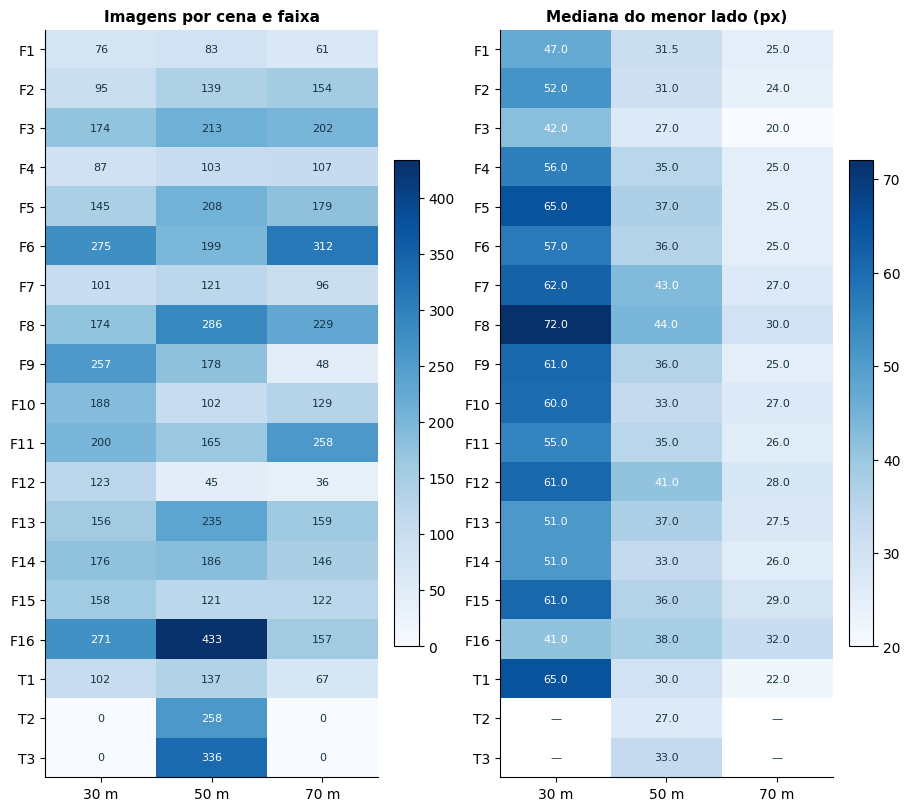

In [12]:
# Cruzamento dentro de cena: expõe a composição que um gráfico agregado por altitude oculta.
matriz_altitude = pd.crosstab(imagens.cena, imagens.faixa_altitude_m).reindex(index=CENAS, columns=[30, 50, 70], fill_value=0)
matriz_escala = caixas.pivot_table(index="cena", columns="faixa_altitude_m", values="menor_lado_px", aggfunc="median").reindex(index=CENAS, columns=[30, 50, 70])
fig, axes = plt.subplots(1, 2, figsize=(9, 8), layout="constrained")
for ax, matriz, titulo, fmt in [(axes[0], matriz_altitude, "Imagens por cena e faixa", ".0f"),
                                (axes[1], matriz_escala, "Mediana do menor lado (px)", ".1f")]:
    desenho = ax.imshow(matriz.to_numpy(), cmap="Blues", aspect="auto")
    ax.set_xticks([0, 1, 2], ["30 m", "50 m", "70 m"])
    ax.set_yticks(range(len(CENAS)), CENAS)
    ax.set_title(titulo, fontsize=11)
    limite = np.nanmax(matriz.to_numpy()) * .55
    for i in range(len(CENAS)):
        for j in range(3):
            valor = matriz.iloc[i, j]
            rotulo = format(valor, fmt) if pd.notna(valor) else "—"
            ax.text(j, i, rotulo, ha="center", va="center", fontsize=8,
                    color="white" if pd.notna(valor) and valor > limite else "#173343")
    fig.colorbar(desenho, ax=ax, shrink=.65)
exibir_figura(fig, "07_altitude_e_escala_por_cena")

## 9. Distribuição espacial das anotações

A posição dos centros das caixas, normalizada pelas dimensões da imagem, permite observar concentrações
espaciais e possíveis efeitos do protocolo de captura ou anotação. A intensidade representa a fração de caixas
em cada célula, de modo que partições com quantidades diferentes possam ser comparadas.

O artigo informa que alvos nas bordas não foram anotados. Assim, regiões com poucas caixas não devem ser
interpretadas automaticamente como ausência de pessoas. A figura descreve as anotações disponíveis.

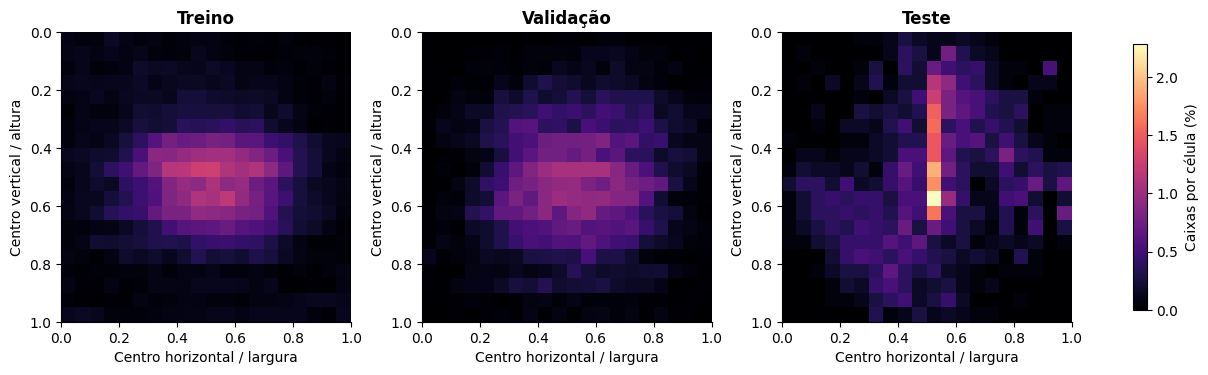

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), layout="constrained")
histogramas = []
for s in PARTICOES:
    grupo = caixas[caixas.split == s]
    h, _, _ = np.histogram2d(grupo.centro_y_norm, grupo.centro_x_norm, bins=20, range=[[0, 1], [0, 1]])
    histogramas.append(100 * h / h.sum())
limite = max(h.max() for h in histogramas)
for ax, s, h in zip(axes, PARTICOES, histogramas):
    grafico = ax.imshow(h, origin="upper", extent=[0, 1, 1, 0], vmin=0, vmax=limite, cmap="magma", aspect="equal")
    ax.set(title=NOMES[s], xlabel="Centro horizontal / largura", ylabel="Centro vertical / altura")
fig.colorbar(grafico, ax=axes, shrink=.8, label="Caixas por célula (%)")
exibir_figura(fig, "08_distribuicao_espacial")

## 10. Separação entre partições: cenas, arquivos e locais de aquisição

A divisão oficial utiliza identificadores de cena distintos. A análise verifica essa separação e procura
arquivos idênticos entre partições. Também consulta as coordenadas da Tabela 4: identificadores distintos
não garantem que os locais geográficos sejam distintos.

In [14]:
conjuntos_cenas = {s: set(imagens.loc[imagens.split == s, "cena"]) for s in PARTICOES}
linhas = []
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    hashes_a = set(imagens.loc[imagens.split == a, "sha256"])
    hashes_b = set(imagens.loc[imagens.split == b, "sha256"])
    linhas.append({"Par": f"{NOMES[a]} × {NOMES[b]}",
                   "Cenas compartilhadas": len(conjuntos_cenas[a] & conjuntos_cenas[b]),
                   "Hashes compartilhados": len(hashes_a & hashes_b)})
display(pd.DataFrame(linhas))
print("Imagens que participam de grupos de arquivos idênticos:", int(imagens.sha256.duplicated(keep=False).sum()))
locais = metadados.groupby("coordenadas_artigo").agg(cenas=("cena", lambda x: ", ".join(x)),
    particoes=("split_artigo", lambda x: ", ".join(sorted(set(x)))),
    numero_particoes=("split_artigo", "nunique"))
display(locais[locais.numero_particoes > 1])

,Par,Cenas compartilhadas,Hashes compartilhados
0,Treino × Validação,0,0
1,Treino × Teste,0,0
2,Validação × Teste,0,0


Imagens que participam de grupos de arquivos idênticos: 0


,cenas,particoes,numero_particoes
coordenadas_artigo,,,
"34°22′59″ N, 108°59′29″ E","F6, T1","test, train",2


As cenas `F6` e `T1` compartilham coordenadas publicadas, embora pertençam a treino e teste e tenham sido
registradas em datas diferentes. Essa coincidência não comprova duplicação de imagens, mas impede afirmar
independência geográfica completa com base apenas nos identificadores de cena. Uma avaliação de
transferência para locais inéditos exigiria controle explícito do local de aquisição.

## 11. Relação com as figuras do artigo e limites de reprodução

| Elemento do artigo | Tratamento neste notebook |
|---|---|
| Figura 1: pares de luz visível e infravermelho | Contextualização conceitual. O pacote POP auditado não fornece uma coleção de pares RGB/térmicos alinhados; os JPEGs de três canais não são tratados como imagens RGB de luz visível. |
| Figura 4: altitudes de aquisição | Exemplos térmicos locais, caixas COCO e recortes com escala fixa. |
| Figura 5: condições meteorológicas | Exemplos locais associados ao clima informado na Tabela 4. |
| Tabela 4: informações por cena | Transcrição com origem explícita e comparação com contagens calculadas. |
| Figura 7: estrutura de diretórios | Leitura direta dos três arquivos COCO, sem conversão para YOLO. |
| Figuras 8(a–c): cenas, altitude e clima | Gráficos recalculados com os arquivos locais; não são estimativas obtidas das barras publicadas. |
| Figura 8(d): oclusão | Não recalculada: faltam rótulos individuais de oclusão nos arquivos auditados. |

O artigo descreve um experimento adicional para estudar taxas de oclusão. Essa medição não deve ser
confundida com uma variável disponível por caixa no conjunto COCO. Não é possível obter a taxa de oclusão
apenas de `area`, `iscrowd`, dimensões da caixa ou intensidade do JPEG.

A comparação entre modalidades exigiria pares alinhados, e a reprodução da contagem por oclusão exigiria
as anotações correspondentes. Nenhuma dessas informações é inferida ou fabricada neste notebook.

## 12. Síntese e continuidade

A exploração acrescenta à apresentação original do dataset quatro verificações: integridade das anotações,
composição das partições por clima, distribuição espacial das caixas e interseção de locais publicados.
A célula seguinte resume os resultados calculados e salva tabelas e figuras em `saidas-eda/`.

A inexistência de imagens sem pessoas limita estudos de falsos alarmes em terrenos vazios. A dependência
entre imagens de uma mesma cena também impede tratá-las automaticamente como observações independentes.
Por isso, não são realizados testes de significância com milhares de quadros como se fossem amostras
independentes.

**Possíveis extensões:** medir semelhança perceptual entre cenas e partições; examinar contraste local entre
caixas e seu entorno, sem interpretar níveis de cinza como temperatura; e obter anotações adicionais de
oclusão para separar esse fator do tamanho aparente.

A etapa seguinte é `01_preparacao_dados.ipynb`, dedicada à conversão para o formato YOLO e à preparação
do experimento. As observações descritivas deste notebook não autorizam reajustar o protocolo com base
em resultados futuros do conjunto de teste.

In [15]:
sintese = {
    "imagens": int(len(imagens)), "caixas": int(len(caixas)), "cenas": int(imagens.cena.nunique()),
    "imagens_sem_pessoas": int(imagens.pessoas.eq(0).sum()),
    "caixas_com_area_coco_inconsistente": int((~np.isclose(caixas.area_coco, caixas.area_px2)).sum()),
    "mediana_menor_lado_px": float(caixas.menor_lado_px.median()),
    "validacao_ensolarada_pct": float(clima_split_pct.loc["Ensolarado", "val"]),
    "nomes_de_cenas_disjuntos": all(not (conjuntos_cenas[a] & conjuntos_cenas[b])
                                  for a, b in [("train", "val"), ("train", "test"), ("val", "test")]),
    "artigo": "https://doi.org/10.1038/s41597-025-04600-0",
    "dataset": "https://osf.io/kmcva/overview",
}
display(pd.Series(sintese, name="Resultado").to_frame())
imagens.to_csv(SAIDAS / "catalogo_eda.csv", index=False)
caixas.to_csv(SAIDAS / "caixas_eda.csv", index=False)
tabela_cenas.to_csv(SAIDAS / "conferencia_tabela4.csv")
(SAIDAS / "sintese.json").write_text(json.dumps(sintese, indent=2, ensure_ascii=False), encoding="utf-8")
(SAIDAS / "ambiente.json").write_text(json.dumps(ambiente, indent=2), encoding="utf-8")
print("Tabelas, figuras e síntese gravadas em saidas-eda/ (pasta ignorada pelo Git).")

,Resultado
imagens,8768
caixas,26811
cenas,19
imagens_sem_pessoas,0
caixas_com_area_coco_inconsistente,26811
mediana_menor_lado_px,34.0
validacao_ensolarada_pct,100.0
nomes_de_cenas_disjuntos,True
artigo,https://doi.org/10.1038/s41597-025-04600-0
dataset,https://osf.io/kmcva/overview


Tabelas, figuras e síntese gravadas em saidas-eda/ (pasta ignorada pelo Git).
